In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

In [2]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12
print("Libraries loaded. Let's learn calculus through code! 🚀")

Libraries loaded. Let's learn calculus through code! 🚀


In [3]:
def numerical_derivative(f, x, h=1e-5):
    return (f(x+h) - f(x-h)) / (2*h)

f = lambda x: x**2
f_prime_analytic = lambda x: 2*x

x_test = 3.0
num_deriv = numerical_derivative(f, x=x_test)
ana_deriv = f_prime_analytic(x_test)

print(f"f(x) = x2 at x = {x_test}")
print(f"Numerical derivative:  {num_deriv:.6f}")
print(f"Analytic  derivative:  {ana_deriv:.6f}")
print(f"Error: {abs(num_deriv - ana_deriv):.2e}")

f(x) = x2 at x = 3.0
Numerical derivative:  6.000000
Analytic  derivative:  6.000000
Error: 3.93e-11


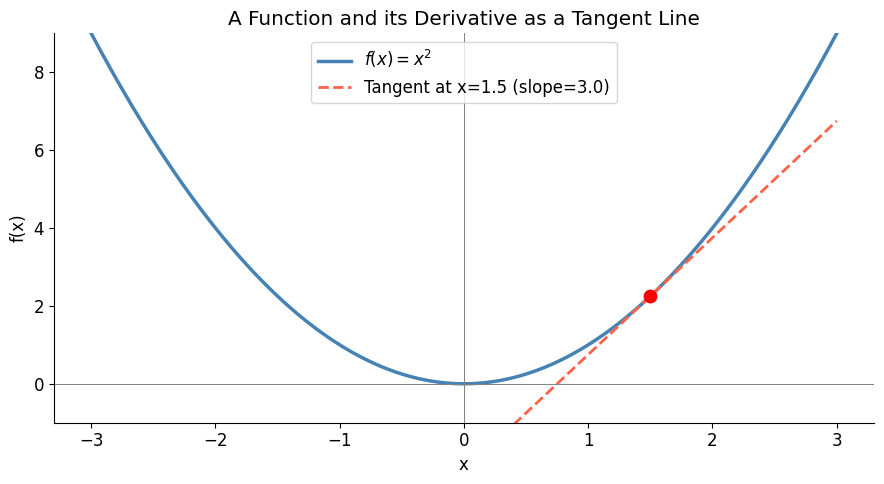

In [4]:
x = np.linspace(-3, 3, 300)
y = x ** 2
x0 = 1.5
slope = f_prime_analytic(x0)
tangent = slope * (x - x0) + f(x0)

plt.figure(figsize=(9, 5))
plt.plot(x, y, 'steelblue', lw=2.5, label=r'$f(x) = x^2$')
plt.plot(x, tangent, 'tomato', lw=2, ls='--', label=f'Tangent at x={x0} (slope={slope})')
plt.scatter([x0], [f(x0)], color='red', s=80, zorder=5)
plt.axhline(0, color='gray', lw=0.7)
plt.axvline(0, color='gray', lw=0.7)
plt.ylim(-1, 9)
plt.legend()
plt.title("A Function and its Derivative as a Tangent Line")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.tight_layout()
plt.show()

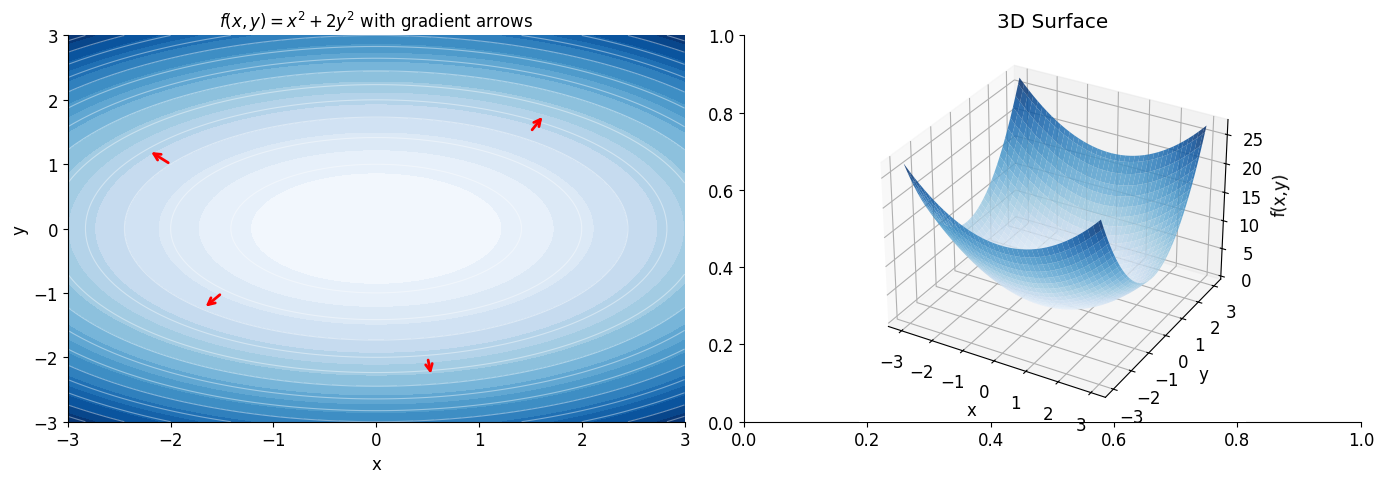

In [5]:
def f2d(x, y):
    return x**2 + 2*y**2

def grad_f2d(x, y):
    return np.array([2*x, 4*y])

x_range = np.linspace(-3, 3, 80)
y_range = np.linspace(-3, 3, 80)
X, Y = np.meshgrid(x_range, y_range)
Z = f2d(X, Y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.contourf(X, Y, Z, levels=25, cmap='Blues')
ax1.contour(X, Y, Z, levels=15, colors='white', alpha=0.4, linewidths=0.8)
sample_pts = [(1.5, 1.5), (-2, 1), (0.5, -2), (-1.5, -1)]
for px, py in sample_pts:
    gx, gy = grad_f2d(px, py)
    ax1.annotate('', xy=(px + 0.3*gx/np.sqrt(gx**2+gy**2),
                         py + 0.3*gy/np.sqrt(gx**2+gy**2)),
                 xytext=(px, py),
                 arrowprops=dict(arrowstyle='->', color='red', lw=2))

ax1.set_title(r'$f(x,y) = x^2 + 2y^2$ with gradient arrows', fontsize=12)
ax1.set_xlabel('x'); ax1.set_ylabel('y')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='Blues', alpha=0.85)
ax2.set_title('3D Surface')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('f(x,y)')

plt.tight_layout()
plt.show()

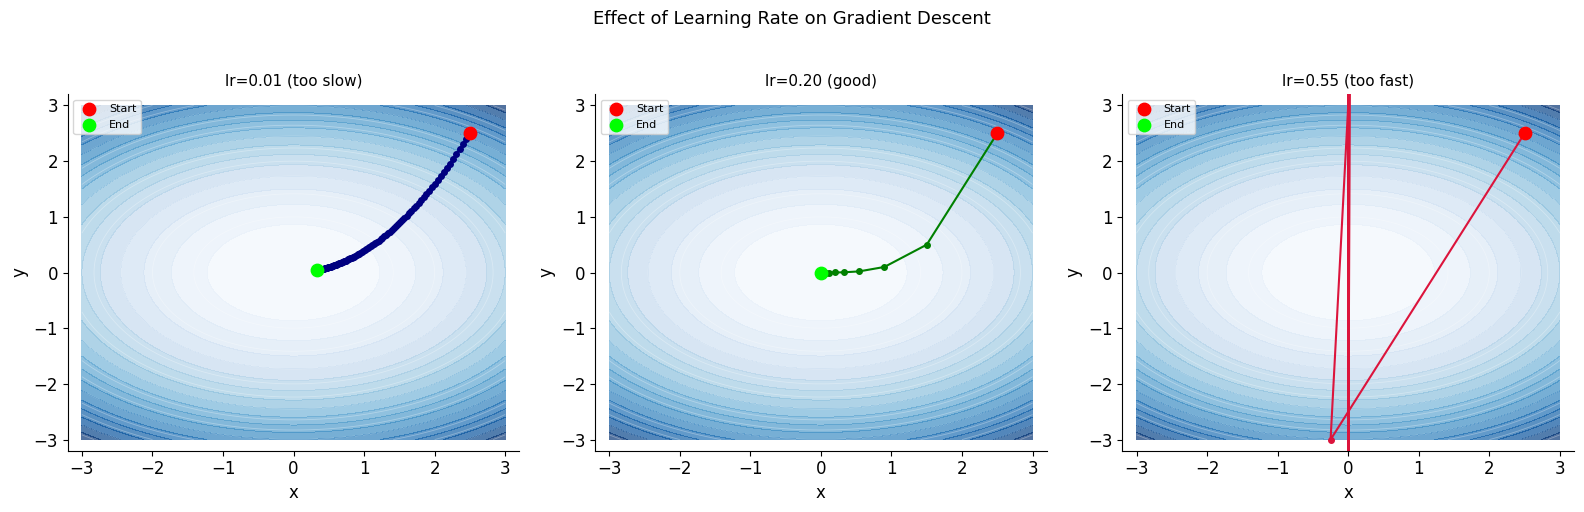

In [10]:
def gradient_descent(grad_fn, start, lr=0.1, n_steps=50):
    path = [np.array(start, dtype=float)]
    pos = np.array(start, dtype=float)
    
    for _ in range(n_steps):
        g = grad_fn(*pos)
        pos = pos - lr * g
        path.append(pos.copy())
    
    return np.array(path)

starts = [2.5, 2.5]
paths = {
    'lr=0.01 (too slow)': gradient_descent(grad_f2d, starts, lr=0.01, n_steps=100),
    'lr=0.20 (good)':     gradient_descent(grad_f2d, starts, lr=0.20, n_steps=30),
    'lr=0.55 (too fast)': gradient_descent(grad_f2d, starts, lr=0.55, n_steps=30),
}

colors = ['navy', 'green', 'crimson']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ((label, path), color) in zip(axes, zip(paths.items(), colors)):
    ax.contourf(X, Y, Z, levels=20, cmap='Blues', alpha=0.7)
    ax.contour(X, Y, Z, levels=15, colors='white', alpha=0.3, linewidths=0.6)
    ax.plot(path[:, 0], path[:, 1], 'o-', color=color, ms=4, lw=1.5)
    ax.scatter(*path[0], color='red', s=80, zorder=5, label='Start')
    ax.scatter(*path[-1], color='lime', s=80, zorder=5, label='End')
    ax.set_title(label, fontsize=11)
    ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
    ax.legend(fontsize=8)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Effect of Learning Rate on Gradient Descent', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

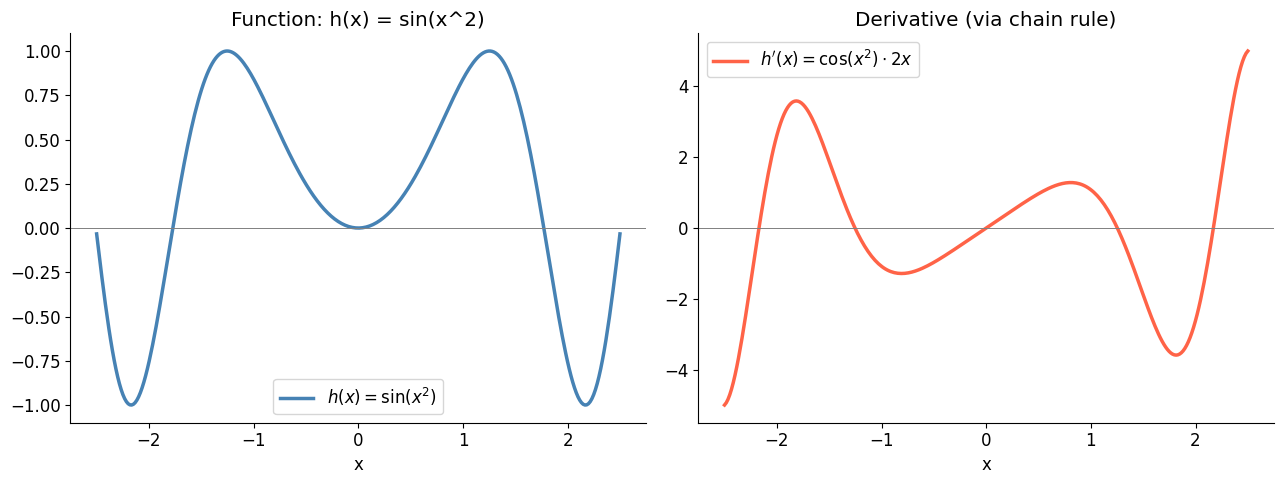

Chain rule verified numerically:
  Analytic:  0.313017
  Numerical: 0.313017


In [13]:
def h(x): return np.sin(x**2)
def dh_dx(x): return np.cos(x**2) * (2 * x)

x = np.linspace(-2.5, 2.5, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(x, h(x), 'steelblue', lw=2.5, label=r'$h(x) = \sin(x^2)$')
axes[0].set_title('Function: h(x) = sin(x^2)'); axes[0].legend()
axes[0].axhline(0, color='gray', lw=0.7)

axes[1].plot(x, dh_dx(x), 'tomato', lw=2.5, label=r"$h'(x) = \cos(x^2) \cdot 2x$")
axes[1].axhline(0, color='gray', lw=0.7)
axes[1].set_title("Derivative (via chain rule)"); axes[1].legend()

for ax in axes: ax.set_xlabel('x')
plt.tight_layout()
plt.show()

print("Chain rule verified numerically:")
x0 = 1.2
print(f"  Analytic:  {dh_dx(x0):.6f}")
print(f"  Numerical: {numerical_derivative(h, x0):.6f}")
